# Rollercoaster Loop Dynamics: Friction, G-Forces and Why Loops Aren't Circles

**Emily Earl**

Can a rollercoaster safely complete a vertical loop, and what does it take to find out? This notebook builds a chain of five models, each feeding the next, and then tests them against real rides:

| # | Model | Method |
|---|-------|--------|
| 1 | Parametric track geometry | Arc-length parameterisation |
| 2 | Energy conservation (frictionless) | Analytical: $v(s) = \sqrt{2g(h_0 - h(s))}$ |
| 3 | Friction ODE | Numerical: `scipy.integrate.solve_ivp` (RK45) |
| 4 | G-force analysis | Normal force from slope and curvature |
| 5 | Circular loop normal force | Analytical: $N(\theta)/mg$ |

The main finding is that friction is a small, correctable error, but a constant-radius (circular) loop is a structural one. Applied to a real ride, the circular model says the loop cannot be completed, even though the ride has run safely since 1977.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.optimize import brentq

os.makedirs("figures", exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 150,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.titlesize": 15,
})

## Physical Parameters
All default parameters are defined here. Functions take them as arguments, so other values can be tested without changing these.

In [2]:
G    = 9.81   # m/s^2          gravitational acceleration
H0   = 30.0   # m              initial drop height
MU   = 0.05   # dimensionless  effective friction coefficient (rolling, bearing and air resistance combined)
R_LP = 8.0    # m              loop radius

SEG_C = ['#e41a1c', '#377eb8', '#ff7f00', '#4daf4a', '#984ea3']
SEG_L = ['Initial drop', 'Run-in flat', 'Vertical loop', 'Exit ramp', 'Final flat']
C = dict(free='#2c7bb6', fric='#d7191c', safe='#1a9641', warn='#fdae61',
         purple='#7b2d8b', limit='#b8860b', ref='#595959')

---
## 1. Parametric Track Geometry

The track is described **parametrically** as $(x(t),\, y(t))$ rather than $y = f(x)$, because the loop has sections where $x$ decreases, making $y = f(x)$ multi-valued.

The independent variable is **arc length** $s$, the distance travelled along the track:

$$s = \int_0^t \sqrt{\left(\frac{dx}{dt}\right)^2 + \left(\frac{dy}{dt}\right)^2}\, dt$$

The slope enters through the unit tangent vector, which stays bounded even on vertical sections:
$$\sin\varphi = \frac{dy}{ds}, \qquad \cos\varphi = \frac{dx}{ds}$$

The **signed curvature** $\kappa = \frac{dx}{ds}\frac{d^2y}{ds^2} - \frac{dy}{ds}\frac{d^2x}{ds^2}$ is positive where the track curves upwards (dips, and the inside of the loop) and negative where it curves downwards (crests). The sign matters: in a dip the centripetal term presses riders into their seats, while over a crest it lifts them out.

| Segment | Shape | Description |
|---------|-------|-------------|
| 0 | Cosine drop | Smooth fall from $h_0$ to ground |
| 1 | Flat | Run-in before the loop |
| 2 | Circular loop | $\phi$ from $0$ to $2\pi$, enters and exits at the bottom |
| 3 | Cosine ramp | Smooth rise to exit hill |
| 4 | Flat | Final braking section |

In [3]:
def build_track(h0=H0, R=R_LP, N=800):
    L_drop, L_flat1, L_exit, L_flat2, h_end = 50.0, 20.0, 25.0, 30.0, 5.0
    segs_x, segs_y, segs_id = [], [], []

    def add(xs, ys, sid):
        segs_x.append(np.asarray(xs))
        segs_y.append(np.asarray(ys))
        segs_id.extend([sid] * len(xs))

    # Segment 0: cosine drop  y = (h0/2)(1 + cos(pi*t/L))
    t = np.linspace(0, L_drop, N)
    add(t, h0 * 0.5 * (1 + np.cos(np.pi * t / L_drop)), 0)

    # Segment 1: flat run-in
    x0, y0, nn = segs_x[-1][-1], segs_y[-1][-1], max(N // 4, 50)
    add(np.linspace(x0, x0 + L_flat1, nn), np.full(nn, y0), 1)

    # Segment 2: vertical loop, phi 0 -> 2pi, entering and exiting at the bottom
    #   x(phi) = x0 + R sin(phi),  y(phi) = y_entry + R (1 - cos(phi))
    x0, y_entry = segs_x[-1][-1], segs_y[-1][-1]
    phi = np.linspace(0, 2 * np.pi, N)
    add(x0 + R * np.sin(phi), y_entry + R * (1 - np.cos(phi)), 2)

    # Segment 3: cosine exit ramp
    x0, y0, nn = segs_x[-1][-1], segs_y[-1][-1], max(N // 4, 50)
    t = np.linspace(0, L_exit, nn)
    add(x0 + t, y0 + (h_end - y0) * 0.5 * (1 - np.cos(np.pi * t / L_exit)), 3)

    # Segment 4: final flat
    x0, y0, nn = segs_x[-1][-1], segs_y[-1][-1], max(N // 4, 50)
    add(np.linspace(x0, x0 + L_flat2, nn), np.full(nn, y0), 4)

    x_raw, y_raw = np.concatenate(segs_x), np.concatenate(segs_y)
    seg_raw = np.array(segs_id)

    # Arc length: cumulative sum of chord lengths (duplicate join points removed)
    s_raw = np.concatenate([[0.0], np.cumsum(np.hypot(np.diff(x_raw), np.diff(y_raw)))])
    _, uniq = np.unique(s_raw, return_index=True)
    s, x, y, seg = s_raw[uniq], x_raw[uniq], y_raw[uniq], seg_raw[uniq]

    # Unit tangent: cos_phi = dx/ds, sin_phi = dy/ds
    dxds, dyds = np.gradient(x, s), np.gradient(y, s)
    mag = np.hypot(dxds, dyds)
    mag = np.where(mag < 1e-12, 1.0, mag)
    cos_phi, sin_phi = dxds / mag, dyds / mag

    # Signed curvature: positive curving upwards (dips, loop), negative over crests
    kappa = cos_phi * np.gradient(sin_phi, s) - sin_phi * np.gradient(cos_phi, s)
    loop = seg == 2
    kappa[loop] = 1.0 / R                                   # exact value on the circle
    kappa[~loop] = np.clip(kappa[~loop], -0.10, 0.10)       # remove spikes at segment joins
    for arr in (sin_phi, cos_phi, kappa):
        arr[~np.isfinite(arr)] = 0.0

    return dict(x=x, y=y, s=s, seg=seg, sin_phi=sin_phi, cos_phi=cos_phi,
                kappa=kappa, h0=h0, R=R)


def loop_span(track):
    m = track['seg'] == 2
    return float(track['s'][m][0]), float(track['s'][m][-1])


def loop_entry_index(track):
    return int(np.where(track['seg'] == 2)[0][0])

In [4]:
track = build_track()
s = track['s']
print(f"Track arc length: {s[-1]:.1f} m  |  points: {len(s)}")
print(f"Points per segment: {[int((track['seg'] == i).sum()) for i in range(5)]}")

Track arc length: 185.6 m  |  points: 2196
Points per segment: [800, 199, 799, 199, 199]


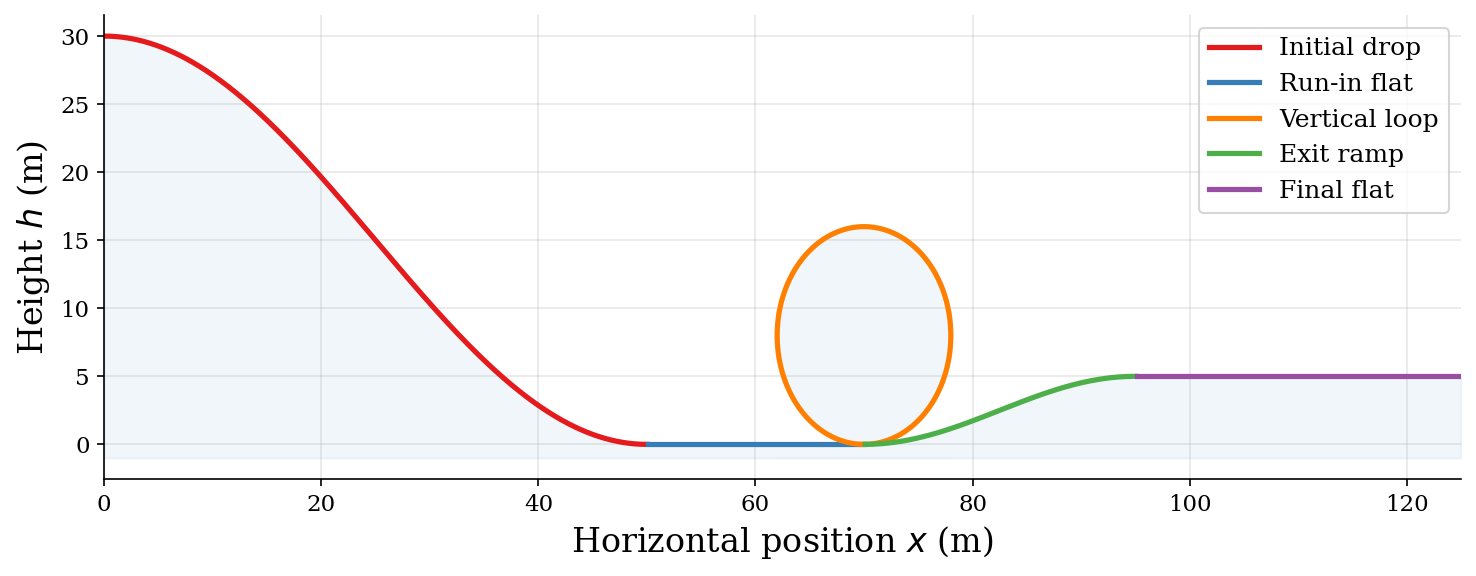

In [5]:
x, y, seg = track['x'], track['y'], track['seg']

fig, ax = plt.subplots(figsize=(10, 4))
for sid in range(5):
    m = seg == sid
    ax.plot(x[m], y[m], color=SEG_C[sid], lw=2.5, label=SEG_L[sid])
ax.fill_between(x, -1, y, alpha=0.08, color='#4393c3')
ax.set_xlabel('Horizontal position $x$ (m)', fontsize=16)
ax.set_ylabel('Height $h$ (m)', fontsize=16)
ax.legend(fontsize=12, loc='upper right')
ax.set_xlim(x[0], x[-1])
fig.tight_layout()
plt.savefig('figures/fig1_track_profile.png', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

---
## 2. Frictionless Energy Conservation

$$\frac{1}{2}mv^2 + mgh = mgh_0 \quad\Longrightarrow\quad
\boxed{v(s) = \sqrt{2g\bigl(h_0 - h(s)\bigr)}}$$

This is purely algebraic, with no ODE needed, and gives the **theoretical upper bound** on speed. The mass cancels, so a full and an empty car travel at the same speed.

In [6]:
def velocity_frictionless(track):
    return np.sqrt(np.maximum(2 * G * (track['h0'] - track['y']), 0.0))


v_free = velocity_frictionless(track)
print(f"Peak speed (frictionless): {np.max(v_free):.2f} m/s  ({np.max(v_free)*3.6:.1f} km/h)")
print(f"Exit speed (frictionless): {v_free[-1]:.2f} m/s")

Peak speed (frictionless): 24.26 m/s  (87.3 km/h)
Exit speed (frictionless): 22.15 m/s


---
## 3. Friction ODE (solved with `solve_ivp`)

The normal force per unit mass combines the component of gravity perpendicular to the track with the centripetal term:
$$\frac{N}{m} = g\cos\varphi + \kappa v^2$$

Newton's second law along the track, with friction $\mu_k |N|$ opposing the motion:
$$v\frac{dv}{ds} = -g\sin\varphi - \mu_k\left|g\cos\varphi + \kappa v^2\right|$$

Substituting $E = \tfrac{1}{2}v^2$ removes the $1/v$ singularity at rest:
$$\boxed{\frac{dE}{ds} = -g\sin\varphi - \mu_k\left|g\cos\varphi + 2\kappa E\right|}, \qquad E(0) = 0$$

The coefficient $\mu_k$ is an effective value that combines rolling resistance, bearing friction and air resistance. Speed is recovered as $v=\sqrt{2E}$.

In [7]:
def friction_ode_solve(track, mu=MU):
    s = track['s']
    f_sp  = interp1d(s, track['sin_phi'], kind='linear', fill_value='extrapolate')
    f_cp  = interp1d(s, track['cos_phi'], kind='linear', fill_value='extrapolate')
    f_kap = interp1d(s, track['kappa'],   kind='linear', fill_value='extrapolate')

    def rhs(s_val, state):
        E = max(state[0], 0.0)
        N_m = G * float(f_cp(s_val)) + 2 * float(f_kap(s_val)) * E   # normal force per unit mass
        return [-G * float(f_sp(s_val)) - mu * abs(N_m)]

    sol = solve_ivp(rhs, t_span=(s[0], s[-1]), y0=[0.0], t_eval=s,
                    method='RK45', rtol=1e-8, atol=1e-10)
    return np.sqrt(2 * np.maximum(sol.y[0], 0.0))

In [8]:
v_fric = friction_ode_solve(track)

exit_loss = (1 - v_fric[-1] / v_free[-1]) * 100
print(f"Peak speed (friction): {np.max(v_fric):.2f} m/s  ({np.max(v_fric)*3.6:.1f} km/h)")
print(f"Exit speed (friction): {v_fric[-1]:.2f} m/s")
print(f"Exit speed loss vs frictionless: {exit_loss:.1f}%")

Peak speed (friction): 22.65 m/s  (81.6 km/h)
Exit speed (friction): 13.29 m/s
Exit speed loss vs frictionless: 40.0%


---
## 4. G-Force Analysis

The g-force a rider feels is the normal force as a multiple of their weight:

$$G = \frac{N}{mg} = \cos\varphi + \frac{\kappa v^2}{g}$$

A stationary rider feels $G = 1$ and a rider in free fall feels $G = 0$. Negative values mean the rider is lifted out of the seat and held in by the restraints. The component of gravity along the track is not felt, because it accelerates rider and car together.

Reference limits: $+6g$ for short durations, and $-2g$ for negative (lifting) forces.

In [9]:
def compute_gforce(track, v):
    return track['cos_phi'] + track['kappa'] * v**2 / G


gf_free = compute_gforce(track, v_free)
gf_fric = compute_gforce(track, v_fric)
print(f"Peak g-force (frictionless): {np.max(gf_free):.2f} g")
print(f"Peak g-force (friction):     {np.max(gf_fric):.2f} g")
print(f"Lowest g-force (friction):   {np.min(gf_fric):.2f} g")

Peak g-force (frictionless): 8.50 g
Peak g-force (friction):     7.20 g
Lowest g-force (friction):   0.12 g


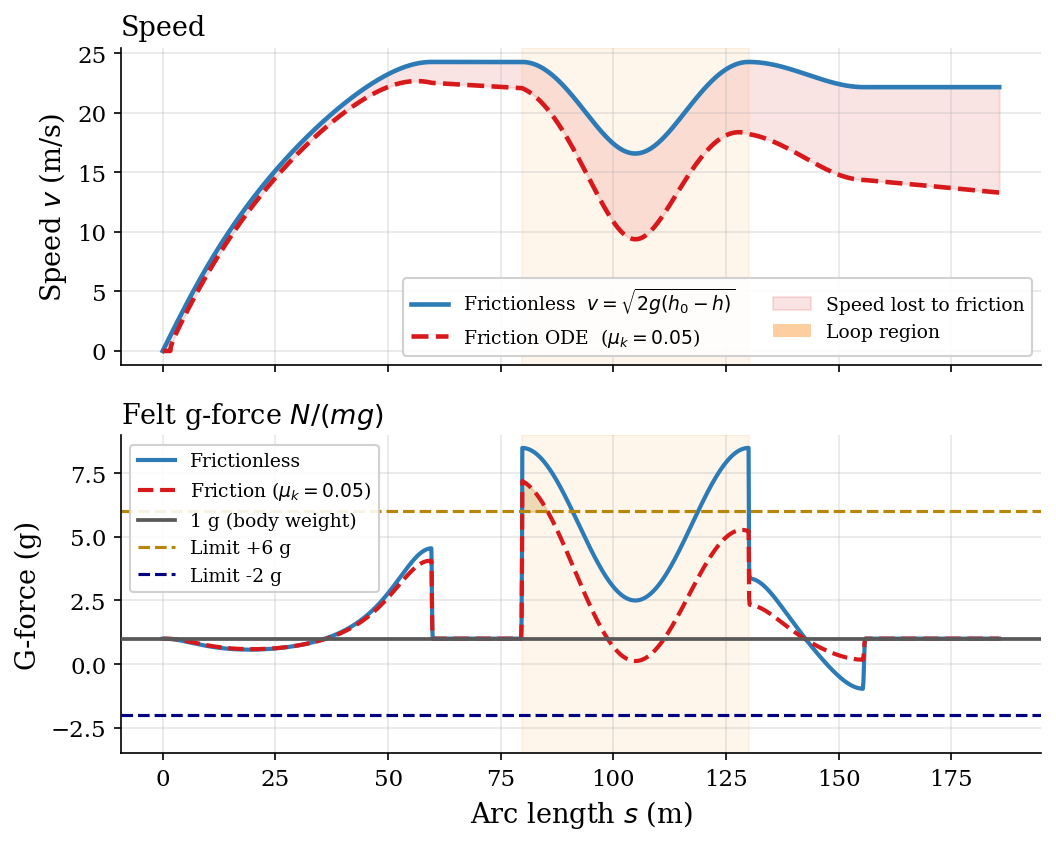

In [10]:
s0, s1 = loop_span(track)
fig, axes = plt.subplots(2, 1, figsize=(7.2, 5.8), sharex=True)

axes[0].plot(s, v_free, color=C['free'], lw=2.2, label=r'Frictionless  $v=\sqrt{2g(h_0-h)}$')
axes[0].plot(s, v_fric, color=C['fric'], lw=2.2, ls='--', label=r'Friction ODE  ($\mu_k={:.2f}$)'.format(MU))
axes[0].fill_between(s, v_fric, v_free, where=(v_free > v_fric + 0.01), alpha=0.12,
                     color=C['fric'], label='Speed lost to friction')
axes[0].axvspan(s0, s1, alpha=0.12, color=C['warn'])
axes[0].set_ylabel('Speed $v$ (m/s)')
axes[0].set_title('Speed', loc='left')
loop_patch = mpatches.Patch(facecolor=C['warn'], alpha=0.6, label='Loop region')
h0_, l0_ = axes[0].get_legend_handles_labels()
axes[0].legend(h0_ + [loop_patch], l0_ + ['Loop region'], ncol=2, loc='lower right',
               fontsize=9, framealpha=0.9)

axes[1].plot(s, gf_free, color=C['free'], lw=2, label='Frictionless')
axes[1].plot(s, gf_fric, color=C['fric'], lw=2, ls='--', label=r'Friction ($\mu_k={:.2f}$)'.format(MU))
axes[1].axhline(1.0, color=C['ref'], lw=1.8, label='1 g (body weight)', zorder=3)
axes[1].axhline(6.0, color=C['limit'], lw=1.5, ls='--', label='Limit +6 g')
axes[1].axhline(-2.0, color='navy', lw=1.5, ls='--', label='Limit -2 g')
axes[1].fill_between(s, gf_fric, 6.0, where=(gf_fric > 6.0), alpha=0.25, color=C['limit'])
axes[1].axvspan(s0, s1, alpha=0.12, color=C['warn'])
axes[1].set_ylim(-3.5, 9)
axes[1].set_xlabel('Arc length $s$ (m)')
axes[1].set_ylabel('G-force (g)')
axes[1].set_title('Felt g-force $N/(mg)$', loc='left')
axes[1].legend(loc='upper left', fontsize=9, framealpha=0.9)

fig.tight_layout()
plt.savefig('figures/fig2_speed_gforce.png', dpi=200, bbox_inches='tight', pad_inches=0.02)
plt.show()

Both models exceed the $+6g$ short-duration limit at the base of the loop, where the track switches abruptly from straight to a tight constant radius at the point of highest speed. This is the first sign that a circular loop is a poor design.

---
## 5. Circular Loop Normal Force (Analytical)

Inside a circular loop of radius $R$, with $\theta$ measured from the bottom and energy conserved within the loop:

$$v(\theta)^2 = v_{\rm bot}^2 - 2gR(1-\cos\theta), \qquad
\frac{N(\theta)}{mg} = \frac{v(\theta)^2}{gR} + \cos\theta = \frac{v_{\rm bot}^2}{gR} - 2 + 3\cos\theta$$

The car stays on the track only while $N \geq 0$ at the top ($\theta=\pi$), which gives the classic minimum entry speed:
$$\boxed{v_{\rm bot} \geq \sqrt{5gR}}$$

In [11]:
def loop_normal_force(R, v_bottom, n=500):
    theta = np.linspace(0, 2 * np.pi, n)
    v2 = np.maximum(v_bottom**2 - 2 * G * R * (1 - np.cos(theta)), 0.0)
    return theta, v2 / (G * R) + np.cos(theta)


def apex_gforce(R, v_bottom):
    return v_bottom**2 / (G * R) - 5


v_bot = float(v_fric[loop_entry_index(track)])
v_min = np.sqrt(5 * G * R_LP)

print(f"Minimum safe entry speed sqrt(5gR): {v_min:.2f} m/s")
print(f"Actual entry speed (friction model): {v_bot:.2f} m/s")
print(f"N/mg at loop top (analytical):       {apex_gforce(R_LP, v_bot):.3f}")
print(f"Loop completable by this criterion:  {'YES' if v_bot >= v_min else 'NO'}")

Minimum safe entry speed sqrt(5gR): 19.81 m/s
Actual entry speed (friction model): 22.05 m/s
N/mg at loop top (analytical):       1.196
Loop completable by this criterion:  YES


---
## 6. Sensitivity Analysis

The friction coefficient $\mu_k$ and drop height $h_0$ are varied independently. For each drop height the track is rebuilt, so the car always starts from rest at the top of a drop of that height.

Beyond $\mu_k \approx 0.10$ the car no longer carries enough speed to complete the loop (section 8.1), so the sweep stops at 0.08.

In [12]:
mu_values = [0.00, 0.02, 0.04, 0.06, 0.08]
h0_values = [20.0, 25.0, 30.0, 35.0, 40.0]

data_mu = {mu: friction_ode_solve(track, mu=mu) for mu in mu_values}
tracks_h0 = {h: build_track(h0=h) for h in h0_values}
data_h0 = {h: friction_ode_solve(tracks_h0[h]) for h in h0_values}

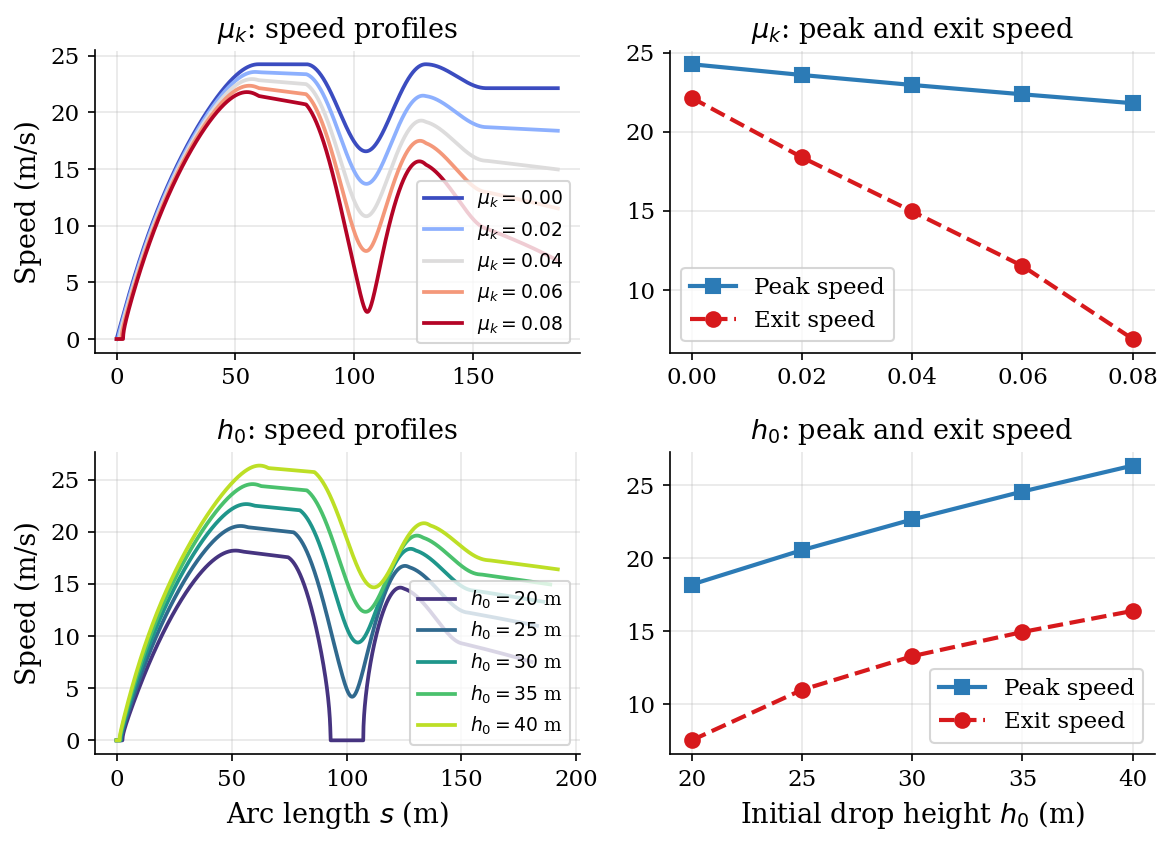

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5.8))

cmap5 = plt.cm.coolwarm(np.linspace(0, 1, len(data_mu)))
for (mu_v, v_arr), col in zip(data_mu.items(), cmap5):
    axes[0, 0].plot(s, v_arr, color=col, lw=1.8, label=r'$\mu_k={:.2f}$'.format(mu_v))
axes[0, 0].set_ylabel('Speed (m/s)')
axes[0, 0].set_title(r'$\mu_k$: speed profiles')
axes[0, 0].legend(fontsize=9)

axes[0, 1].plot(mu_values, [np.max(v) for v in data_mu.values()], 's-', color=C['free'], lw=2, ms=7, label='Peak speed')
axes[0, 1].plot(mu_values, [float(v[-1]) for v in data_mu.values()], 'o--', color=C['fric'], lw=2, ms=7, label='Exit speed')
axes[0, 1].set_title(r'$\mu_k$: peak and exit speed')
axes[0, 1].legend()

cmap6 = plt.cm.viridis(np.linspace(0.15, 0.9, len(data_h0)))
for (h_v, v_arr), col in zip(data_h0.items(), cmap6):
    axes[1, 0].plot(tracks_h0[h_v]['s'], v_arr, color=col, lw=1.8, label=r'$h_0={:.0f}$ m'.format(h_v))
axes[1, 0].set_xlabel('Arc length $s$ (m)')
axes[1, 0].set_ylabel('Speed (m/s)')
axes[1, 0].set_title(r'$h_0$: speed profiles')
axes[1, 0].legend(fontsize=9)

axes[1, 1].plot(h0_values, [np.max(v) for v in data_h0.values()], 's-', color=C['free'], lw=2, ms=7, label='Peak speed')
axes[1, 1].plot(h0_values, [float(v[-1]) for v in data_h0.values()], 'o--', color=C['fric'], lw=2, ms=7, label='Exit speed')
axes[1, 1].set_xlabel('Initial drop height $h_0$ (m)')
axes[1, 1].set_title(r'$h_0$: peak and exit speed')
axes[1, 1].legend()

fig.tight_layout()
plt.savefig('figures/fig3_sensitivity.png', dpi=200, bbox_inches='tight', pad_inches=0.02)
plt.show()

Friction barely changes the peak speed, which is reached early, but steadily erodes the exit speed, because its effect accumulates with distance. Peak speed grows like $\sqrt{h_0}$, so doubling the drop height does not double the speed.

---
## 7. Energy Budget: Where Is Energy Lost?

The gap between the frictionless and friction kinetic energies,
$$\Delta E(s) = E_{\rm free}(s) - E_{\rm fric}(s),$$
is the cumulative work done against friction. As a check on the numerical integration, it should equal the friction work computed directly by the trapezium rule,
$$\int_0^s \mu_k \left|N(s')\right|/m \; ds', \qquad N/m = g\cos\varphi + 2\kappa E_{\rm fric}.$$

In [14]:
E_free = 0.5 * v_free**2
E_fric = 0.5 * v_fric**2
dE = E_free - E_fric                                   # cumulative friction loss

N_m = G * track['cos_phi'] + 2 * track['kappa'] * E_fric
W_cum = cumulative_trapezoid(MU * np.abs(N_m), s, initial=0.0)

discrepancy = abs(dE[-1] - W_cum[-1]) / dE[-1] * 100
print(f"Total energy lost (ODE):            {dE[-1]:.4f} J/kg")
print(f"Total work against friction (sum):  {W_cum[-1]:.4f} J/kg")
print(f"Relative discrepancy:               {discrepancy:.4f} %")

rows = []
for sid in range(5):
    m = track['seg'] == sid
    seg_loss = dE[m][-1] - dE[m][0]
    seg_len = s[m][-1] - s[m][0]
    rows.append([SEG_L[sid], seg_len, seg_loss, seg_loss / seg_len, 100 * seg_loss / dE[-1]])

df_energy = pd.DataFrame(rows, columns=['Segment', 'Length (m)', 'Energy lost (J/kg)',
                                        'Rate (J/kg/m)', '% of total'])
df_energy.round(2)

Total energy lost (ODE):            156.9191 J/kg
Total work against friction (sum):  156.9205 J/kg
Relative discrepancy:               0.0009 %


,Segment,Length (m),Energy lost (J/kg),Rate (J/kg/m),% of total
0,Initial drop,59.72,41.02,0.69,26.14
1,Run-in flat,19.90,9.87,0.50,6.29
2,Vertical loop,50.20,77.24,1.54,49.22
3,Exit ramp,25.48,13.58,0.53,8.66
4,Final flat,29.85,14.64,0.49,9.33


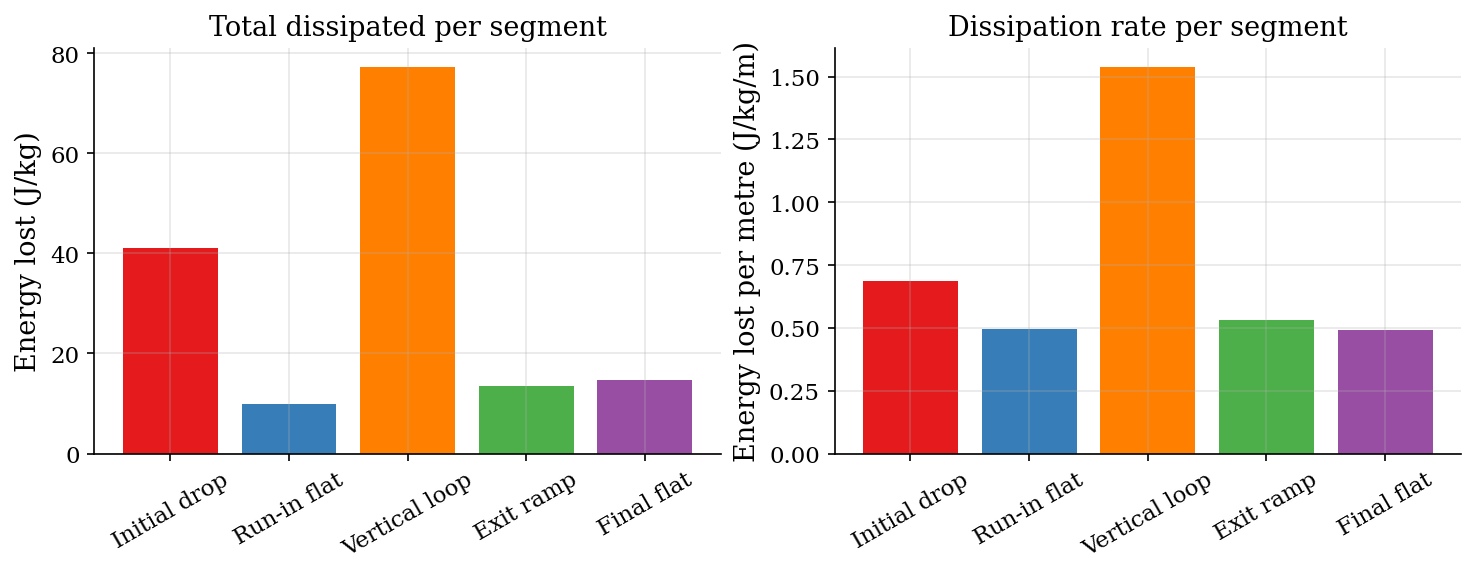

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(SEG_L, df_energy['Energy lost (J/kg)'], color=SEG_C)
axes[0].set_ylabel('Energy lost (J/kg)')
axes[0].set_title('Total dissipated per segment')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(SEG_L, df_energy['Rate (J/kg/m)'], color=SEG_C)
axes[1].set_ylabel('Energy lost per metre (J/kg/m)')
axes[1].set_title('Dissipation rate per segment')
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.savefig('figures/fig4_segment_dissipation.png', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

The loop dissipates energy about three times faster per metre than the flat sections. Its curvature inflates the normal force through the $2\kappa E$ term, and friction grows with it. A constant-deceleration friction model could not capture this.

---
## 8. Loop Safety: Analytical versus Friction-Inclusive

The analytical loop model (section 5) assumes no energy is lost *inside* the loop. Here both models start from the same friction-inclusive entry speed and use the same formula $N/(mg) = v(\theta)^2/(gR) + \cos\theta$. The only difference is whether $v(\theta)$ conserves energy within the loop or comes from the friction ODE.

In [16]:
m = track['seg'] == 2
x_loop, y_loop, v_loop = track['x'][m], track['y'][m], v_fric[m]
x0, y_entry = x_loop[0], y_loop[0]

cos_th = 1 - (y_loop - y_entry) / R_LP
sin_th = (x_loop - x0) / R_LP
theta = np.unwrap(np.arctan2(sin_th, cos_th))
theta[theta < -1e-6] += 2 * np.pi
theta_deg = np.degrees(theta)

v_bottom = v_loop[0]
v2_an = np.maximum(v_bottom**2 - 2 * G * R_LP * (1 - np.cos(theta)), 0.0)
Nmg_an = v2_an / (G * R_LP) + np.cos(theta)       # frictionless within the loop
Nmg_num = v_loop**2 / (G * R_LP) + np.cos(theta)  # friction ODE speeds

i_top = np.argmin(np.abs(theta - np.pi))
print(f"N/mg at loop top, analytical: {Nmg_an[i_top]:.3f}")
print(f"N/mg at loop top, friction:   {Nmg_num[i_top]:.3f}")
print(f"Apex margin reduced by a factor of {Nmg_an[i_top] / Nmg_num[i_top]:.1f}")

N/mg at loop top, analytical: 1.196
N/mg at loop top, friction:   0.121
Apex margin reduced by a factor of 9.9


### 8.1 How Much Friction Would Make the Loop Fail?

The completion condition $v_{\rm bot} \geq \sqrt{5gR}$ is itself a frictionless result. Using the $\mu_k$ sweep from section 6, we find the critical friction coefficient $\mu_{\rm crit}$ at which the loop entry speed falls to this limit.

In [17]:
i_entry = loop_entry_index(track)
v_bot_vals = [v_arr[i_entry] for v_arr in data_mu.values()]
v_bot_free = v_free[i_entry]

print(f"v_min = sqrt(5gR)         = {v_min:.3f} m/s")
print(f"Entry speed, frictionless = {v_bot_free:.3f} m/s  (margin {100*(v_bot_free - v_min)/v_min:+.1f}%)")
print(f"Entry speed, mu = {MU}     = {v_bot:.3f} m/s  (margin {100*(v_bot - v_min)/v_min:+.1f}%)")

mu_crit = brentq(lambda mu: friction_ode_solve(track, mu=mu)[i_entry] - v_min, 0.05, 0.15, xtol=1e-5)
print(f"\nmu_crit (loop fails at entry) = {mu_crit:.4f}")
print(f"Safety factor on mu_k         = {mu_crit / MU:.2f}x")

v_min = sqrt(5gR)         = 19.809 m/s
Entry speed, frictionless = 24.261 m/s  (margin +22.5%)
Entry speed, mu = 0.05     = 22.051 m/s  (margin +11.3%)



mu_crit (loop fails at entry) = 0.0993
Safety factor on mu_k         = 1.99x


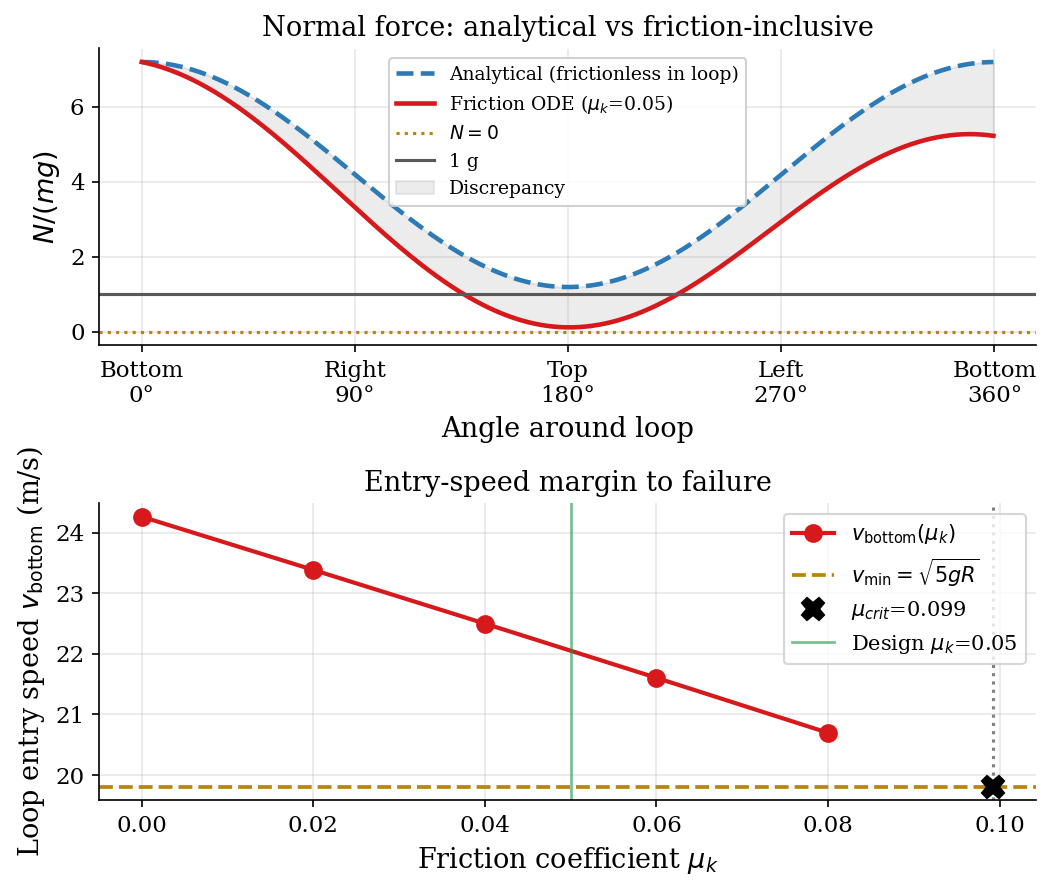

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.1))

axes[0].plot(theta_deg, Nmg_an, color=C['free'], lw=2.2, ls='--', label='Analytical (frictionless in loop)')
axes[0].plot(theta_deg, Nmg_num, color=C['fric'], lw=2.2, label=r'Friction ODE ($\mu_k$={:.2f})'.format(MU))
axes[0].axhline(0, color=C['limit'], lw=1.5, ls=':', label='$N=0$')
axes[0].axhline(1, color=C['ref'], lw=1.5, label='1 g')
axes[0].fill_between(theta_deg, Nmg_an, Nmg_num, alpha=0.15, color='gray', label='Discrepancy')
axes[0].set_xticks([0, 90, 180, 270, 360])
axes[0].set_xticklabels(['Bottom\n0°', 'Right\n90°', 'Top\n180°', 'Left\n270°', 'Bottom\n360°'])
axes[0].set_xlabel('Angle around loop')
axes[0].set_ylabel('$N/(mg)$')
axes[0].set_title('Normal force: analytical vs friction-inclusive')
axes[0].legend(fontsize=9, loc='upper center', framealpha=0.9)

axes[1].plot(mu_values, v_bot_vals, 'o-', color=C['fric'], lw=2, ms=8, label=r'$v_{\rm bottom}(\mu_k)$')
axes[1].axhline(v_min, color=C['limit'], ls='--', lw=1.8, label=r'$v_{\min}=\sqrt{5gR}$')
axes[1].axvline(mu_crit, color='gray', ls=':', lw=1.5)
axes[1].plot(mu_crit, v_min, 'X', color='k', ms=11, zorder=5, label=r'$\mu_{{crit}}$={:.3f}'.format(mu_crit))
axes[1].axvline(MU, color=C['safe'], ls='-', lw=1.3, alpha=0.6, label=r'Design $\mu_k$={:.2f}'.format(MU))
axes[1].set_xlabel(r'Friction coefficient $\mu_k$')
axes[1].set_ylabel(r'Loop entry speed $v_{\rm bottom}$ (m/s)')
axes[1].set_title('Entry-speed margin to failure')
axes[1].legend(fontsize=10)

fig.tight_layout()
plt.savefig('figures/fig5_loop_safety.png', dpi=200, bbox_inches='tight', pad_inches=0.02)
plt.show()

The $\sqrt{5gR}$ criterion certifies this loop as safe, but once friction inside the loop is included the apex margin almost vanishes. A frictionless safety criterion can be dangerously optimistic.

---
## 9. Real-Ride Validation A: The Friction Model (Shockwave, Drayton Manor)

Shockwave (1994; converted to a sit-down coaster and renamed *The Wave* in 2024) is a chain-lift Intamin coaster whose first drop feeds straight into a vertical loop, the closest real match to this track. Published figures: first drop 32 m (105 ft), top speed 23.6 m/s (53 mph), peak g-force 4g.

We find the friction coefficient $\mu_{\rm eff}$ that reproduces the published speed at the bottom of the drop, and compare it with the design value $\mu_k = 0.05$ used above.

In [19]:
H0_SW = 32.0      # Shockwave first drop (m)
V_SW = 23.6       # published top speed (m/s), 53 mph
G_SW = 4.0        # published peak g-force

track32 = build_track(h0=H0_SW)
s32 = track32['s']
i_drop = np.where(track32['seg'] == 0)[0][-1]

v_free32 = velocity_frictionless(track32)
v_ideal = v_free32[i_drop]
energy_retained = (V_SW / v_ideal)**2
print(f"Frictionless prediction at drop bottom: {v_ideal:.2f} m/s")
print(f"Published top speed:                    {V_SW:.2f} m/s")
print(f"Energy retained: {100*energy_retained:.1f}%  (loss {100*(1-energy_retained):.1f}%)")

mu_eff = brentq(lambda mu: friction_ode_solve(track32, mu=mu)[i_drop] - V_SW, 0.0, 0.3, xtol=1e-5)
v_design32 = friction_ode_solve(track32, mu=MU)[i_drop]
print(f"\nmu_eff fitted to Shockwave:   {mu_eff:.4f}")
print(f"Speed predicted at mu = {MU}: {v_design32:.2f} m/s ({100*(v_design32 - V_SW)/V_SW:+.1f}% vs published)")

# Radius a circular loop base would need to give the published 4g at this speed:
# N/(mg) = v^2/(gR) + 1 at the bottom  ->  R = v^2 / ((G_rating - 1) g)
R_SW = V_SW**2 / ((G_SW - 1) * G)
print(f"\nBottom-of-loop radius implied by {G_SW:.0f}g at {V_SW} m/s: R = {R_SW:.2f} m")

Frictionless prediction at drop bottom: 25.06 m/s
Published top speed:                    23.60 m/s
Energy retained: 88.7%  (loss 11.3%)



mu_eff fitted to Shockwave:   0.0409
Speed predicted at mu = 0.05: 23.28 m/s (-1.4% vs published)

Bottom-of-loop radius implied by 4g at 23.6 m/s: R = 18.92 m


The fitted $\mu_{\rm eff}$ is slightly below the design value, so the design value errs on the safe side by slightly overstating losses. Even without fitting, running the model at $\mu_k = 0.05$, a value chosen with no reference to this ride, predicts the drop speed to within a few percent. The friction half of the model passes.

---
## 10. Real-Ride Validation B: The Circular Loop (SooperDooperLooper, Hersheypark)

SooperDooperLooper (Schwarzkopf and Stengel, 1977) has a single drop into a documented loop: drop height about 21 m (70 ft), top speed 20.1 m/s (45 mph), and a 57 ft (17.4 m) vertical loop. A circle of that height has $R \approx 8.7$ m.

With a real $R$ and a real entry speed, does the circular model predict that the loop can be completed?

In [20]:
R_SDL = 8.7       # circle matched to the 57 ft loop height
H0_SDL = 21.0     # approximate drop height (70 ft)
V_SDL = 20.1168   # 45 mph in m/s

v_free_sdl = np.sqrt(2 * G * H0_SDL)
v_min_sdl = np.sqrt(5 * G * R_SDL)

print(f"v_free (frictionless, h0 = {H0_SDL} m): {v_free_sdl:.3f} m/s")
print(f"v_real (published, 45 mph):         {V_SDL:.3f} m/s")
print(f"v_min = sqrt(5gR), R = {R_SDL} m:      {v_min_sdl:.3f} m/s")
print()
print(f"v_free - v_min = {v_free_sdl - v_min_sdl:+.3f} m/s ({100*(v_free_sdl - v_min_sdl)/v_min_sdl:+.1f}%)")
print(f"v_real - v_min = {V_SDL - v_min_sdl:+.3f} m/s ({100*(V_SDL - v_min_sdl)/v_min_sdl:+.1f}%)")
print(f"\nCircular-model g-force at the loop base: {V_SDL**2/(G*R_SDL) + 1:.1f} g")

v_free (frictionless, h0 = 21.0 m): 20.298 m/s
v_real (published, 45 mph):         20.117 m/s
v_min = sqrt(5gR), R = 8.7 m:      20.658 m/s

v_free - v_min = -0.359 m/s (-1.7%)
v_real - v_min = -0.541 m/s (-2.6%)

Circular-model g-force at the loop base: 5.7 g


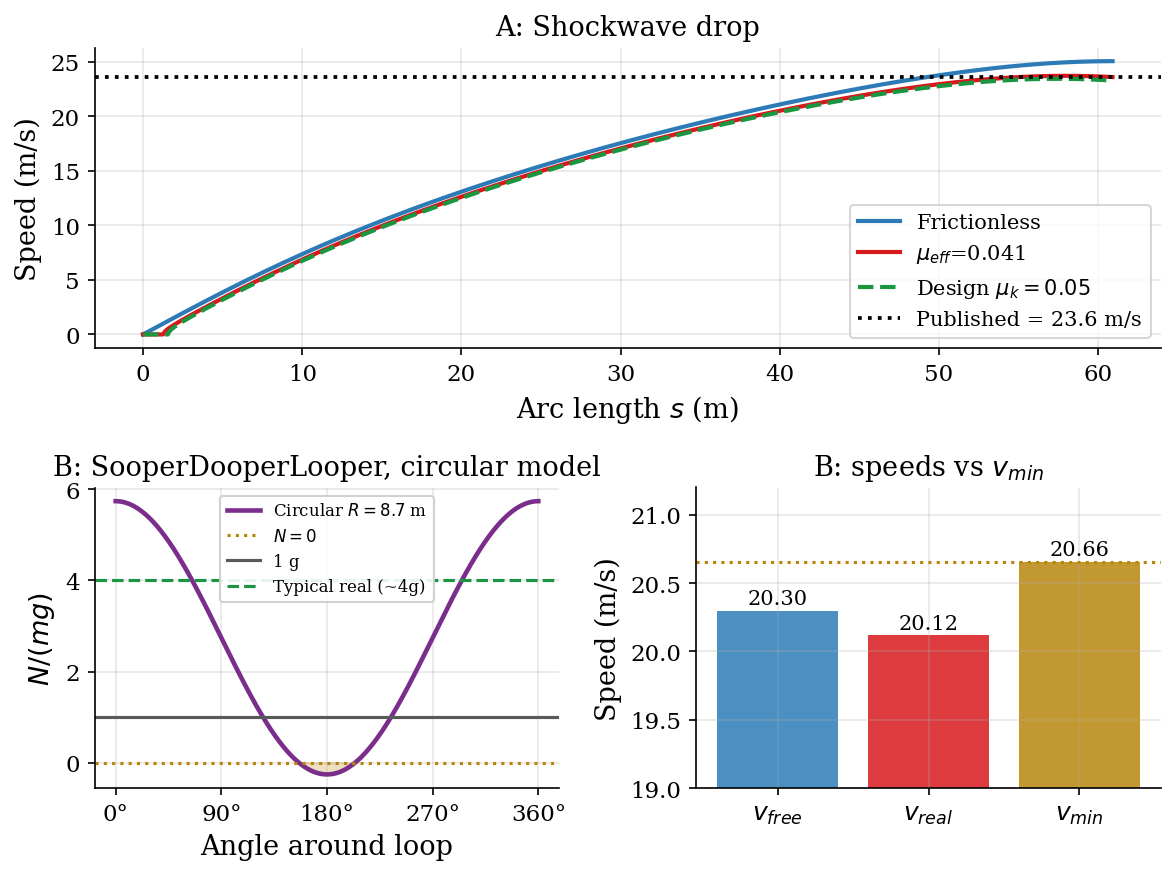

In [21]:
v_fric_eff = friction_ode_solve(track32, mu=mu_eff)
v_fric_design = friction_ode_solve(track32, mu=MU)
s_drop = s32[:i_drop + 1]

fig, axd = plt.subplot_mosaic([['A', 'A'], ['B', 'C']], figsize=(8, 6.0))

axd['A'].plot(s_drop, v_free32[:i_drop + 1], color=C['free'], lw=2, label='Frictionless')
axd['A'].plot(s_drop, v_fric_eff[:i_drop + 1], color=C['fric'], lw=2, label=r'$\mu_{{eff}}$={:.3f}'.format(mu_eff))
axd['A'].plot(s_drop, v_fric_design[:i_drop + 1], color=C['safe'], lw=2, ls='--', label=r'Design $\mu_k={:.2f}$'.format(MU))
axd['A'].axhline(V_SW, color='k', ls=':', lw=1.8, label=f'Published = {V_SW} m/s')
axd['A'].set_xlabel('Arc length $s$ (m)')
axd['A'].set_ylabel('Speed (m/s)')
axd['A'].set_title('A: Shockwave drop')
axd['A'].legend(fontsize=10)

theta_sdl, Nmg_sdl = loop_normal_force(R=R_SDL, v_bottom=V_SDL)
theta_sdl_deg = np.degrees(theta_sdl)
axd['B'].plot(theta_sdl_deg, Nmg_sdl, color=C['purple'], lw=2.2, label=f'Circular $R={R_SDL}$ m')
axd['B'].axhline(0, color=C['limit'], ls=':', lw=1.5, label='$N=0$')
axd['B'].axhline(1, color=C['ref'], lw=1.5, label='1 g')
axd['B'].axhline(4.0, color=C['safe'], ls='--', lw=1.5, label='Typical real (~4g)')
axd['B'].fill_between(theta_sdl_deg, Nmg_sdl, 0, where=(Nmg_sdl < 0), color=C['limit'], alpha=0.25)
axd['B'].set_xticks([0, 90, 180, 270, 360])
axd['B'].set_xticklabels(['0°', '90°', '180°', '270°', '360°'])
axd['B'].set_xlabel('Angle around loop')
axd['B'].set_ylabel('$N/(mg)$')
axd['B'].set_title('B: SooperDooperLooper, circular model')
axd['B'].legend(fontsize=8, loc='upper center', framealpha=0.9)

labels = [r'$v_{free}$', r'$v_{real}$', r'$v_{min}$']
vals = [v_free_sdl, V_SDL, v_min_sdl]
bars = axd['C'].bar(labels, vals, color=[C['free'], C['fric'], C['limit']], alpha=0.85)
axd['C'].axhline(v_min_sdl, color=C['limit'], ls=':', lw=1.5)
for b, v in zip(bars, vals):
    axd['C'].text(b.get_x() + b.get_width() / 2, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)
axd['C'].set_ylabel('Speed (m/s)')
axd['C'].set_ylim(19, 21.2)
axd['C'].set_title('B: speeds vs $v_{min}$')
axd['C'].tick_params(axis='x', labelsize=12)

fig.tight_layout()
plt.savefig('figures/fig6_realdata_validation.png', dpi=200, bbox_inches='tight')
plt.show()

The minimum speed the circular model requires exceeds both the ride's published speed and even its frictionless maximum. Taken literally, the circular model says a loop that has run safely since 1977 cannot be completed. It also over-predicts the g-force at the loop base compared with the roughly 4g measured on comparable loops. The error is not numerical. It is the assumption of a constant radius.

### 10.1 Loop Shapes Across Three Rides

The Great American Revolution (Six Flags Magic Mountain, 1976), the first modern coaster with a vertical loop, has a loop published as **90 ft tall and 45 ft wide**. No circle can be twice as tall as it is wide. Comparing radii across the three rides shows the same pattern.

In [22]:
FT = 0.3048
summary = pd.DataFrame({
    'Coaster': ['SooperDooperLooper', 'Great American Revolution', 'Shockwave'],
    'R (m)': [R_SDL, 45 * FT, R_SW],
    'Basis': ['Circle matched to 57 ft loop height',
              'Circle matched to 90 ft loop height',
              'Base radius implied by 4g rating (section 9)'],
})
summary.round(1)

,Coaster,R (m),Basis
0,SooperDooperLooper,8.7,Circle matched to 57 ft loop height
1,Great American Revolution,13.7,Circle matched to 90 ft loop height
2,Shockwave,18.9,Base radius implied by 4g rating (section 9)


The radii of circles matched to each loop's height (8.7–13.7 m) are smaller than the base radius needed to hold the force to 4g (18.9 m). Real loops are broad at the base and tight at the top. This is the **clothoid** (teardrop) loop introduced on the Great American Revolution, whose curvature increases towards the top so the rider's load stays moderate throughout. That single change in shape fixes both failures of the circular model: the excessive g-force at the base and the vanishing margin at the top.

---
## 11. Summary of Results

In [23]:
results = pd.DataFrame({
    'Quantity': [
        'Track arc length',
        'Peak speed, frictionless',
        f'Peak speed, friction (mu = {MU})',
        'Exit speed, frictionless',
        f'Exit speed, friction (mu = {MU})',
        'Exit speed lost to friction',
        'Peak g-force, frictionless',
        'Peak g-force, friction',
        'Loop entry speed (friction model)',
        'Minimum safe entry speed sqrt(5gR)',
        'N/mg at loop top, analytical',
        'N/mg at loop top, friction-inclusive',
        'Critical friction coefficient mu_crit',
        'mu_eff fitted to Shockwave',
    ],
    'Value': [
        f'{s[-1]:.1f} m',
        f'{np.max(v_free):.2f} m/s ({np.max(v_free)*3.6:.1f} km/h)',
        f'{np.max(v_fric):.2f} m/s ({np.max(v_fric)*3.6:.1f} km/h)',
        f'{v_free[-1]:.2f} m/s',
        f'{v_fric[-1]:.2f} m/s',
        f'{exit_loss:.1f}%',
        f'{np.max(gf_free):.2f} g',
        f'{np.max(gf_fric):.2f} g',
        f'{v_bot:.2f} m/s',
        f'{v_min:.2f} m/s',
        f'{Nmg_an[i_top]:.3f}',
        f'{Nmg_num[i_top]:.3f}',
        f'{mu_crit:.3f}',
        f'{mu_eff:.3f}',
    ],
})
results.set_index('Quantity')

,Value
Quantity,
Track arc length,185.6 m
"Peak speed, frictionless",24.26 m/s (87.3 km/h)
"Peak speed, friction (mu = 0.05)",22.65 m/s (81.6 km/h)
"Exit speed, frictionless",22.15 m/s
"Exit speed, friction (mu = 0.05)",13.29 m/s
Exit speed lost to friction,40.0%
"Peak g-force, frictionless",8.50 g
"Peak g-force, friction",7.20 g
Loop entry speed (friction model),22.05 m/s


## Limitations

- **Two dimensions only.** Real tracks bank and twist, which adds lateral forces.
- **One effective friction coefficient.** Rolling, bearing and air resistance are combined into a single constant. Air resistance really grows with speed squared, so this understates losses at high speed and overstates them at low speed.
- **Idealised geometry.** The circular loop is joined directly to a straight track, which is what produces the sudden jump in g-force at its base. Real tracks use transition curves.
- **Published ride data.** The validation relies on manufacturer and park figures (speed, height, g-rating), not measured speed profiles.